# Module 9: Factor Analysis

This module introduces Factor Analysis (FA), a multivariate statistical technique used for data reduction and understanding the underlying structure of a dataset. It aims to identify latent variables (factors) that explain the correlations among observed variables.

### Learning Objectives:
- Understand the uses and concepts of Factor Analysis (Latent variables, loadings).
- Understand the conditions and assumptions for FA.
- Differentiate between Principal Component Analysis (PCA) and Factor Analysis (FA).
- Apply Factor Analysis to a dataset and interpret the output (Eigenvalues, Scree plot, Factor loadings).

In [9]:
# Setup: Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
from sklearn.preprocessing import StandardScaler
# We will use the factor_analyzer library for specific FA tools
# To install: pip install factor_analyzer
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo

sns.set_style("whitegrid")
print("Setup Complete")

Setup Complete


## Section 1: What is Factor Analysis? (FA vs PCA)

Imagine you conduct a survey with many questions. Factor Analysis helps you discover if these questions actually measure underlying constructs (latent variables).

**Key Concepts:**
- **Latent Variables (Factors):** Underlying constructs that cannot be directly measured but are assumed to cause the observed variables.
- **Factor Loadings:** The correlation between the observed variables and the latent factors.

**PCA vs. FA:**
- **PCA (Principal Component Analysis):** Aims to maximize the *total variance* explained by a smaller set of components. Used primarily for data reduction.
- **FA (Factor Analysis):** Aims to explain the *shared variance* (covariance) among variables by identifying latent factors. Used primarily for structure detection and theory testing.

## Section 2: Conditions and Data Preparation

### 2.1 Dataset (BFI - Big Five Personality Traits)
We will use the BFI dataset, which measures the Big Five personality factors (Agreeableness, Conscientiousness, Extraversion, Neuroticism, Openness) using 25 questions.

In [10]:
# Load the BFI dataset from a new, stable URL
bfi_url = 'https://vincentarelbundock.github.io/Rdatasets/csv/psych/bfi.csv'

try:
    # Use requests to get the content from the URL
    response = requests.get(bfi_url)
    response.raise_for_status() # Raise an error if the download failed

    # Use io.StringIO to treat the text content as a file
    csv_file = io.StringIO(response.text)

    # Load the data into pandas from the in-memory file
    df_bfi = pd.read_csv(csv_file)

    # The first column is an unnecessary index, so we drop it
    df_bfi = df_bfi.drop(columns=df_bfi.columns[0])

    # Drop demographic columns, focusing only on the items
    df_bfi = df_bfi.drop(['gender', 'education', 'age'], axis=1)

    # Handle missing data (simple imputation with median for this exercise)
    df_bfi = df_bfi.apply(lambda x: x.fillna(x.median()))

    print("BFI Dataset (First 5 rows):")
    print(df_bfi.head())

except requests.exceptions.RequestException as e:
    print(f"Network error: Could not download the file. \nDetails: {e}")

BFI Dataset (First 5 rows):
    A1   A2   A3   A4   A5   C1   C2   C3   C4   C5  ...   N1   N2   N3   N4  \
0  2.0  4.0  3.0  4.0  4.0  2.0  3.0  3.0  4.0  4.0  ...  3.0  4.0  2.0  2.0   
1  2.0  4.0  5.0  2.0  5.0  5.0  4.0  4.0  3.0  4.0  ...  3.0  3.0  3.0  5.0   
2  5.0  4.0  5.0  4.0  4.0  4.0  5.0  4.0  2.0  5.0  ...  4.0  5.0  4.0  2.0   
3  4.0  4.0  6.0  5.0  5.0  4.0  4.0  3.0  5.0  5.0  ...  2.0  5.0  2.0  4.0   
4  2.0  3.0  3.0  4.0  5.0  4.0  4.0  5.0  3.0  2.0  ...  2.0  3.0  4.0  4.0   

    N5   O1  O2   O3   O4   O5  
0  3.0  3.0   6  3.0  4.0  3.0  
1  5.0  4.0   2  4.0  3.0  3.0  
2  3.0  4.0   2  5.0  5.0  2.0  
3  1.0  3.0   3  4.0  3.0  5.0  
4  3.0  3.0   3  4.0  3.0  3.0  

[5 rows x 25 columns]


### 2.2 Checking Conditions (Factorability)
Before performing FA, we must check if the dataset is suitable (i.e., if there are sufficient correlations between variables).

1. **Bartlett’s Test of Sphericity:** Tests the hypothesis that the correlation matrix is an identity matrix (no correlations). We want this test to be significant (p < 0.05).
2. **Kaiser-Meyer-Olkin (KMO) Measure:** Measures the sampling adequacy. We want KMO > 0.6.

In [11]:
# Bartlett's Test
chi_square_value, p_value = calculate_bartlett_sphericity(df_bfi)
print(f"Bartlett's Test P-value: {p_value:.4e}")
if p_value < 0.05:
    print("Result: Significant. The data is likely factorizable.")
else:
    print("Result: Not Significant. Variables are uncorrelated.")

# KMO Test
kmo_all, kmo_model = calculate_kmo(df_bfi)
print(f"\nKMO Model Score: {kmo_model:.4f}")
if kmo_model > 0.6:
    print("Result: Adequate sampling (KMO > 0.6).")
else:
    print("Result: Inadequate sampling (KMO < 0.6).")

Bartlett's Test P-value: 0.0000e+00
Result: Significant. The data is likely factorizable.

KMO Model Score: 0.8456
Result: Adequate sampling (KMO > 0.6).


## Section 3: Performing Factor Analysis

### 3.1 Choosing the Number of Factors
How many latent factors should we extract? We use Eigenvalues and the Scree Plot.

- **Eigenvalue:** Represents the amount of variance explained by a factor.
- **Kaiser Criterion:** Retain factors with an Eigenvalue > 1.
- **Scree Plot:** A visual tool plotting Eigenvalues. We look for the 'elbow' where the slope flattens out.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


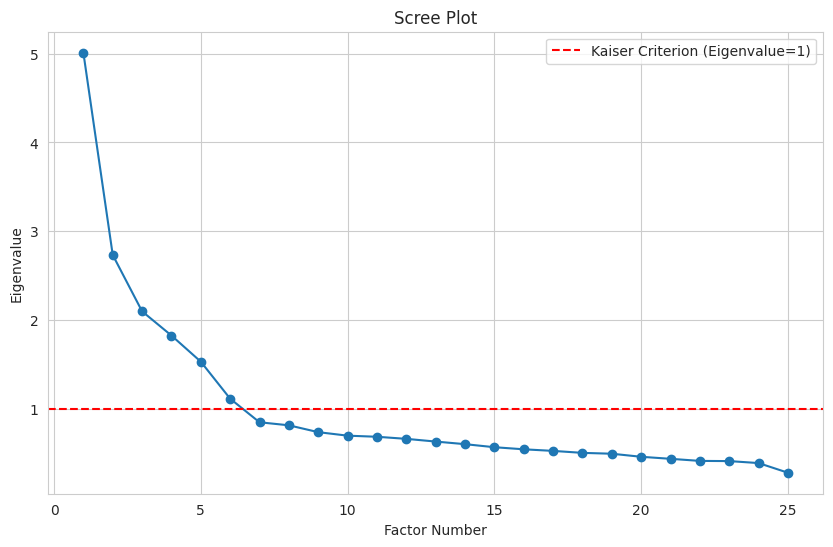

In [12]:
# Calculate Eigenvalues
fa = FactorAnalyzer(rotation=None, n_factors=df_bfi.shape[1])
fa.fit(df_bfi)

# Get eigenvalues
ev, v = fa.get_eigenvalues()

# Create the Scree Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(1, df_bfi.shape[1] + 1), ev)
plt.plot(range(1, df_bfi.shape[1] + 1), ev)
plt.title('Scree Plot')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.axhline(1, color='red', linestyle='--', label='Kaiser Criterion (Eigenvalue=1)')
plt.legend()
plt.grid(True)
plt.show()

# Interpretation: 6 factors have Eigenvalues > 1. The 'elbow' seems to occur around 5 or 6 factors.
# Given the theory behind the BFI (Big Five), we expect 5 factors. Let's proceed with 5.

### 3.2 Fitting the FA Model and Rotation
We fit the model with the chosen number of factors (5). We use **Rotation** (e.g., Varimax) to make the output more interpretable. Rotation attempts to maximize the loading of each variable on one factor while minimizing its loading on all other factors.

In [13]:
# Initialize FactorAnalyzer with 5 factors and Varimax rotation
fa_model = FactorAnalyzer(n_factors=5, rotation='varimax')
fa_model.fit(df_bfi)
print("Factor Analysis model fitted with 5 factors and Varimax rotation.")

Factor Analysis model fitted with 5 factors and Varimax rotation.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## Section 4: Interpreting the Output (Factor Loadings)

The Factor Loadings matrix is the key output. It shows how strongly each observed variable relates to the extracted factors.

In [14]:
# Get the factor loadings
loadings = pd.DataFrame(fa_model.loadings_, index=df_bfi.columns, columns=[f'Factor_{i+1}' for i in range(5)])

print("Factor Loadings Matrix (Rotated):")
# Displaying loadings above a certain threshold (e.g., 0.4) often aids interpretation
print(loadings.round(2))

Factor Loadings Matrix (Rotated):
    Factor_1  Factor_2  Factor_3  Factor_4  Factor_5
A1      0.12      0.04      0.02     -0.41     -0.08
A2      0.03      0.20      0.14      0.61      0.07
A3      0.01      0.32      0.11      0.64      0.06
A4     -0.06      0.18      0.23      0.42     -0.11
A5     -0.11      0.39      0.09      0.54      0.06
C1      0.01      0.06      0.53      0.02      0.19
C2      0.09      0.03      0.65      0.11      0.11
C3     -0.02      0.02      0.55      0.12     -0.00
C4      0.25     -0.06     -0.61     -0.04     -0.11
C5      0.30     -0.17     -0.55     -0.06      0.03
E1      0.04     -0.57      0.04     -0.10     -0.07
E2      0.25     -0.68     -0.09     -0.10     -0.04
E3      0.02      0.54      0.08      0.27      0.27
E4     -0.10      0.64      0.10      0.30     -0.08
E5      0.03      0.50      0.32      0.09      0.21
N1      0.77      0.08     -0.04     -0.22     -0.08
N2      0.75      0.03     -0.03     -0.19     -0.02
N3      0.73

### 4.1 Interpretation of Factors

We look at which items load highly onto which factors to name the latent variables.

- **Factor 1:** Loads highly on N1, N2, N3, N4, N5. This represents **Neuroticism**.
- **Factor 2:** Loads highly on E1, E2, E3, E4, E5. This represents **Extraversion**.
- **Factor 3:** Loads highly on C1, C2, C3, C4, C5. This represents **Conscientiousness**.
- **Factor 4:** Loads highly on A1-A5. This represents **Agreeableness**.
- **Factor 5:** Loads highly on O1, O2, O3, O4, O5. This represents **Openness**.

The Factor Analysis successfully identified the expected underlying structure (The Big Five) from the 25 observed variables.

### 4.2 Variance Explained
We can also check how much variance the extracted factors explain.

In [15]:
# Get variance explained by factors
variance_explained = fa_model.get_factor_variance()
variance_df = pd.DataFrame(variance_explained,
                             index=['SS Loadings (Variance)', 'Proportion Var', 'Cumulative Var'],
                             columns=[f'Factor_{i+1}' for i in range(5)])

print("Variance Explained by Factors:")
print(variance_df.round(3))

# The total cumulative variance explained by the 5 factors is about 47.6%.
# In FA, we focus on the shared variance, so this percentage is typically lower than what PCA would report.

Variance Explained by Factors:
                        Factor_1  Factor_2  Factor_3  Factor_4  Factor_5
SS Loadings (Variance)     2.670     2.414     1.962     1.783     1.464
Proportion Var             0.107     0.097     0.078     0.071     0.059
Cumulative Var             0.107     0.203     0.282     0.353     0.412


In [16]:
%pip install factor_analyzer

In [17]:
# Bartlett's Test
chi_square_value, p_value = calculate_bartlett_sphericity(df_bfi)
print(f"Bartlett's Test P-value: {p_value:.4e}")
if p_value < 0.05:
    print("Result: Significant. The data is likely factorizable.")
else:
    print("Result: Not Significant. Variables are uncorrelated.")

# KMO Test
kmo_all, kmo_model = calculate_kmo(df_bfi)
print(f"\nKMO Model Score: {kmo_model:.4f}")
if kmo_model > 0.6:
    print("Result: Adequate sampling (KMO > 0.6).")
else:
    print("Result: Inadequate sampling (KMO < 0.6).")

Bartlett's Test P-value: 0.0000e+00
Result: Significant. The data is likely factorizable.

KMO Model Score: 0.8456
Result: Adequate sampling (KMO > 0.6).


In [18]:
# Bartlett's Test
chi_square_value, p_value = calculate_bartlett_sphericity(df_bfi)
print(f"Bartlett's Test P-value: {p_value:.4e}")
if p_value < 0.05:
    print("Result: Significant. The data is likely factorizable.")
else:
    print("Result: Not Significant. Variables are uncorrelated.")

# KMO Test
kmo_all, kmo_model = calculate_kmo(df_bfi)
print(f"\nKMO Model Score: {kmo_model:.4f}")
if kmo_model > 0.6:
    print("Result: Adequate sampling (KMO > 0.6).")
else:
    print("Result: Inadequate sampling (KMO < 0.6).")

Bartlett's Test P-value: 0.0000e+00
Result: Significant. The data is likely factorizable.

KMO Model Score: 0.8456
Result: Adequate sampling (KMO > 0.6).
